In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import minmax_scale

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 0
plt.rcParams['grid.alpha'] = 0.6
plt.rcParams['pdf.fonttype'] = 42

# TCGA

In [30]:
from utils import tcga
from utils.os_utils import QuantileSampleSplitPlot, QuantileSampleSplit, CPHfited, ScatterCoxPlot, PartialEffectPlot
dftcga = tcga.load_cancer_expr(cancer_type=['GBM'], survival_type = 'PFI')

In [31]:
related_priors = {}
with open('../assets/ZhaoSim2021/related_priors.txt') as f:
    for line in f:
        prior, *genes = line.strip().split(' ')
        related_priors[prior] = genes

In [32]:
from topicvi.prior import load_metaprograms
metaprograms = load_metaprograms('Malignant')

## Assign scores to TCGA samples

In [12]:
selected_prior = 'Cell-Cycle-Checkpoints-R-HSA-69620'
dftcga['score'] = dftcga.loc[:,dftcga.columns.isin(related_priors[selected_prior])].mean(axis=1)

In [33]:
topic_weights = pd.read_table('../assets/ZhaoSim2021/topic32_weights.tsv', index_col=0)
topic_weights = topic_weights[topic_weights.index.isin(dftcga.columns)]
dftcga['score'] = dftcga.loc[:, topic_weights.index] @ topic_weights

## Log-rank Test Analysis

In [77]:
best_p = 1
best_q = 1
for q in np.linspace(0.1,0.5,10):
    p = QuantileSampleSplit(dftcga,gene = 'score', q=q, verbose=False)
    if p < best_p:
        best_p = p
        best_q = q

best_p, best_q

(0.02720519765127613, 0.23333333333333334)

Text(0, 0.5, 'Survival probability')

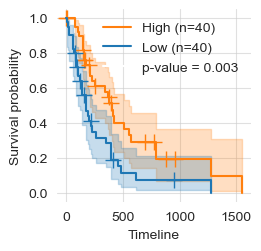

In [18]:
f, ax = plt.subplots(1,1, figsize=(2.5,2.5))
QuantileSampleSplitPlot(dftcga, gene = 'score', q=0.25, ax = ax, show_censors=True)
ax.set_title('')
ax.set_xlabel('Timeline')
ax.set_ylabel('Survival probability')
# f.savefig(f'../assets/ZhaoSim2021/{selected_prior}_TCGA_survival.pdf', bbox_inches='tight')

In [44]:
dftcga['score'] = minmax_scale(dftcga['score'])
CPHfited(dftcga[['OS', 'OS.time', 'score']])#['exp(coef)']['score']

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
score,-1.06979,0.34308,0.440032,-1.932237,-0.207344,0.144824,0.81274,0.0,-2.431165,0.01505,6.05406


### Search for Related Metaprograms

In [13]:
for prior in metaprograms:
    genes = metaprograms[prior]
    overlap = len(set(genes) & set(dftcga.columns))
    if overlap >= 5:
        dftcga['score'] = dftcga.loc[:,dftcga.columns.isin(genes)].mean(axis=1)
        dftcga['score'] = minmax_scale(dftcga['score'])
        p = QuantileSampleSplit(dftcga, gene = 'score', q=0.25, verbose=False)
        cph_result = CPHfited(dftcga[['OS', 'OS.time', 'score']])
        if cph_result.shape[0] == 0:
            hazard_ratio = np.nan
        else:
            hazard_ratio = cph_result['coef']['score']
            cph_p = cph_result['p']['score']
            print(prior, p, hazard_ratio, cph_p)


Chromatin  0.05016661633459243 -1.1482722700880115 0.016222655395118628
Stress  0.019887957218039966 2.0837682151418364 0.0005473823348314411
Hypoxia 0.08390003051565983 1.2118986169524457 0.012443784741955628
Unfolded protein response 0.04412585743619538 1.3158598442018676 0.021409559707440184
Protein maturation 0.003556660509728677 2.002772340306359 3.8037898922401395e-05
EMT-II 0.0020801286857881286 2.876083630474457 6.590817853457283e-06
EMT-III  0.09443793773960493 1.3122388438561956 0.009522617662721661
EMT-IV 0.009769727501424071 1.5357212372499727 0.005869587642194039
MES (glioma) 0.04552703741102193 1.3402736023376378 0.0043814705342294456
Interferon-MHC-II (II) 0.002351089019844994 1.0382049742517683 0.013233755722978297
Epithelial Senescence 0.010611071871520281 1.0675973167885777 0.006254174841134544
Secreted I 0.06256112924398409 4.154078814609383 1.1429437989269465e-05
Oligo Progenitor 0.02982632404794367 -1.2270511167731222 0.02569466399033549
NPC-OPC 0.00338345963436696

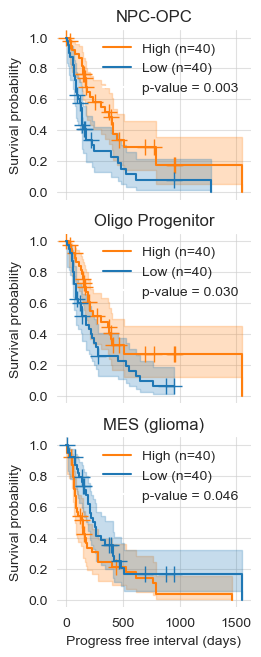

In [10]:
selected_priors = [
    'NPC-OPC',
    'Oligo Progenitor',
    'MES (glioma)'
]

f, axes = plt.subplots(3, 1, figsize=(2.5, 7.5), sharex=True)
for selected_prior, ax in zip(selected_priors, axes):
    dftcga['score'] = dftcga.loc[:,dftcga.columns.isin(metaprograms[selected_prior])].mean(axis=1)
    dftcga['score'] = minmax_scale(dftcga['score'])
    QuantileSampleSplitPlot(dftcga, gene = 'score', q=0.25, ax = ax, show_censors=True)
    ax.set_title('')
    # ax.set_xticklabels([])
    ax.set_xlabel('Progress free interval (days)')
    ax.set_title(selected_prior)
    ax.set_ylabel('Survival probability')
# f.tight_layout()
f.savefig(f'../assets/ZhaoSim2021/metaprogram_TCGA_survival.pdf', bbox_inches='tight')

# Cox Proportional Hazards Model

In [25]:
for t in [12, 32]:
    topic_weights = pd.read_table(f'../assets/ZhaoSim2021/topic{t}_weights.tsv', index_col=0)
    topic_weights = topic_weights[topic_weights.index.isin(dftcga.columns)]
    dftcga[f'Topic {t}_score'] = dftcga.loc[:, topic_weights.index] @ topic_weights
    dftcga[f'Topic {t}_score'] = minmax_scale(dftcga[f'Topic {t}_score'])
for prior, genes in metaprograms.items():
    dftcga[f'{prior}_score'] = dftcga.loc[:,dftcga.columns.isin(genes)].mean(axis=1)
    dftcga[f'{prior}_score'] = minmax_scale(dftcga[f'{prior}_score'])

for prior, genes in related_priors.items():
    prior = '_'.join(list(related_priors.keys())[0].split('-')[-3:])
    dftcga[f'{prior}_score'] = dftcga.loc[:,dftcga.columns.isin(genes)].mean(axis=1)
    dftcga[f'{prior}_score'] = minmax_scale(dftcga[f'{prior}_score'])

In [26]:
from lifelines import CoxPHFitter

df_plot = []
# single variable CoxPH
for score in dftcga.filter(like='score').columns:
    cph = CoxPHFitter()
    cph.fit(dftcga[['OS', 'OS.time', score]], 'OS.time', event_col='OS')
    summary = cph.summary
    df_plot.append({
        'covariate': score,
        'HR': summary['coef'][0],
        'CI_lower': summary['coef lower 95%'][0],
        'CI_upper': summary['coef upper 95%'][0],
        '-log2(p)': -np.log2(summary['p'][0]),
        'p': summary['p'][0],
    })

df_plot = pd.DataFrame(df_plot)
# cph = CoxPHFitter()
# cph.fit(dftcga[['OS', 'OS.time'] + dftcga.filter(like='score').columns.tolist()], 'OS.time', event_col='OS')
# # cph.plot(hazard_ratios=True)

# summary = cph.summary
# df_plot = summary.reset_index()
# df_plot['HR'] = df_plot['coef']
# df_plot['CI_lower'] = df_plot['coef lower 95%']
# df_plot['CI_upper'] = df_plot['coef upper 95%']
df_plot.drop(index=[42], inplace=True)

In [27]:
from statsmodels.stats.multitest import multipletests
df_plot['fdr'] = multipletests(df_plot['p'], method='fdr_bh')[1]
df_plot['-log2(p)'] = -np.log2(df_plot['fdr'])

In [28]:
df_plot.sort_values('HR', inplace=True)
df_plot.reset_index(drop=True, inplace=True)

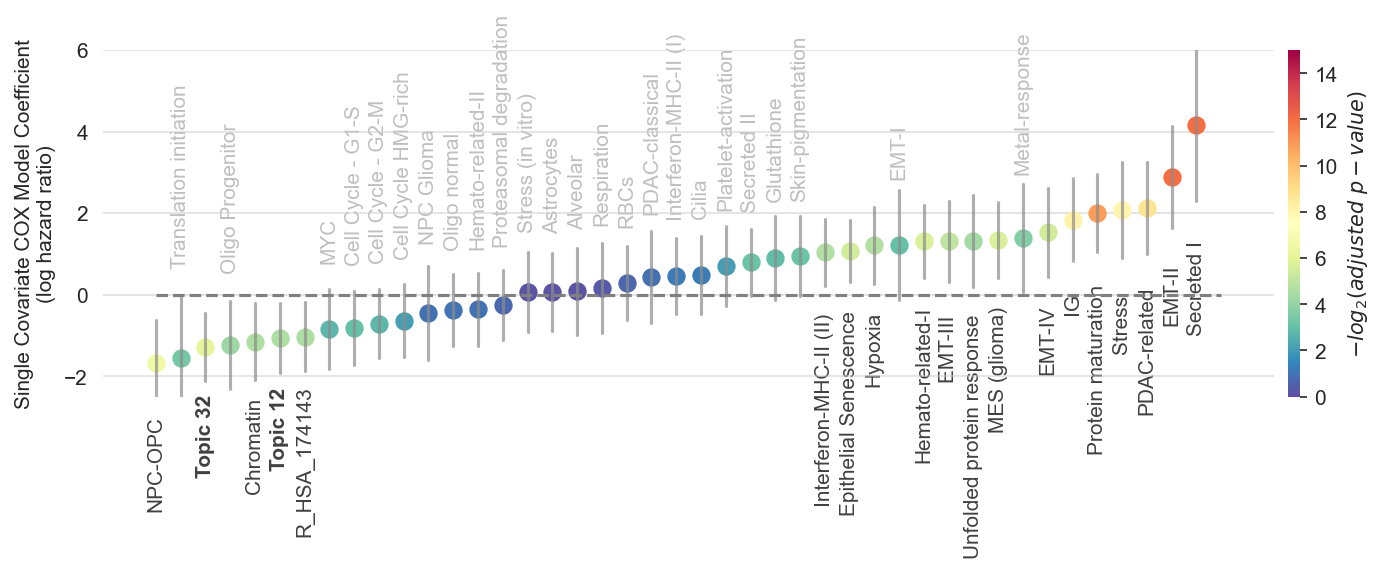

In [29]:
plt.figure(figsize=(12, 3), dpi=150)
# capsize = 0
ax = sns.pointplot(
    y='HR', 
    x='covariate', 
    data=df_plot, # last one is Unassigned_score from metaprograms, not explainable
    join=False, 
    palette = 'Spectral_r',
    # color='black', 
    # make color based on column "HR"
    hue='-log2(p)',
    hue_norm=(0, 15),
    markers='o', 
)

# for i, row in df_plot.iterrows():
#     ax.plot([row['CI_lower'], row['CI_upper']], [i, i], color='.55', alpha=0.7, )

for i, row in df_plot.iterrows():
    ax.plot([i, i], [row['CI_lower'], row['CI_upper']], color='.55', alpha=0.7, )

ax.set_ylim(-2.5, 6)
ax.hlines(y = 0, xmin = 0, xmax = df_plot.shape[0], colors = 'grey', linestyles = 'dashed')
# ax.legend(
#     title='$-log_2(p-value)$',
#     bbox_to_anchor=(0.15, 1.2),
#     loc='upper left',
#     borderaxespad=0.,
#     frameon=False,
#     ncol=5
# )
# chnge to colorbar legend
norm = plt.Normalize(0, 15)
sm = plt.cm.ScalarMappable(cmap="Spectral_r", norm=norm)
sm.set_array([])
cbar = ax.get_figure().colorbar(sm, ax=ax, #orientation='horizontal', 
                                location='right',
                                pad=0.01, aspect=30)
cbar.set_label('$-log_2(adjusted\ p-value)$')
ax.get_legend().remove()

new_ticks = []
for t in ax.get_xticklabels():
    t.set_text(t.get_text().replace('_score',''))
    if t.get_text() in ['Topic 12', 'Topic 32']:
        t.set_fontweight('bold')
    # make transformer based on HR (tick position is index)
    t.set_transform(ax.get_xaxis_transform())
    # if p_val < 0.05: set color .75
    if df_plot.query(f"covariate == '{t.get_text()}_score'")['-log2(p)'].values[0] < -np.log2(0.05):
        t.set_color('.75')
        t.set_y(
            df_plot.query(f"covariate == '{t.get_text()}_score'")['CI_upper'].values[0] / 10 + 0.37,
        )
        t.set_va('bottom')
    else:
        t.set_y(
            df_plot.query(f"covariate == '{t.get_text()}_score'")['CI_lower'].values[0] / 10 + 0.22,
        )
        t.set_color('.25')
    new_ticks.append(t.get_text())
ax.set_xticklabels(new_ticks, rotation=90)

ax.set_ylabel('Single Covariate COX Model Coefficient\n(log hazard ratio)')
ax.set_xlabel('')

plt.savefig('../assets/ZhaoSim2021/TCGA_survival_forest.pdf', bbox_inches='tight')

# Survival Analysis with EGFR

In [34]:
mc3 = pd.read_table("D:/Data/TCGA/mc3.v0.2.8.PUBLIC.xena.gz", compression='gzip')
target_genes = ['EGFR', 'SEC61G', 'LANCL2', 'VOPP1', 'CCT6A']
egfr_mut_sample = mc3.query("gene in @target_genes")['sample']
egfr_mut_sample=dftcga.index[dftcga.index.isin(egfr_mut_sample)]

In [35]:
dftcga['EGFR_mut'] = dftcga.index.isin(egfr_mut_sample).astype(int)
dftcga['age'] = tcga.dataos.set_index('sample')['age_at_initial_pathologic_diagnosis']
dftcga['gender'] = tcga.dataos.set_index('sample')['gender']
dftcga['race'] = tcga.dataos.set_index('sample')['race']
dftcga['EGFR_score_interaction'] = dftcga['score'] * dftcga['EGFR_mut']
dftcga['score'] = minmax_scale(dftcga['score'])

In [36]:
from lifelines import CoxPHFitter
cph_all = CoxPHFitter()
cph_all.fit(
    dftcga[['OS', 'OS.time', 'score', 'EGFR_mut', 'age', 'gender', 'race', 'EGFR_score_interaction']].dropna(),
    'OS.time', event_col='OS',
    formula="score + EGFR_mut + age + gender + race + EGFR_score_interaction",
    robust=True,
    # show_progress=False,
)
cph_all.print_summary()

<lifelines.CoxPHFitter: fitted with 157 total observations, 33 right-censored observations>
             duration col = 'OS.time'
                event col = 'OS'
          robust variance = True
      baseline estimation = breslow
   number of observations = 157
number of events observed = 124
   partial log-likelihood = -502.33
         time fit was run = 2026-02-26 09:52:50 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
score                             -1.51      0.22      0.53           -2.55           -0.47                0.08                0.62
EGFR_mut                           0.21      1.24      0.20           -0.18            0.61                0.83                1.84
age                                0.01      1.01      0.01           -0.00            0.03                1.00                1.03
gender[T.MALE]                     0.20      1.22      0.19           -0.18            0.58                0.84                1.78
race[T.BLACK OR AFRICAN AMERICAN]  1.02      2.76      0.79           -0.53            2.56                0.59               12.93
race[T.WHITE]                      0.11      1.12      0.68           -1.22            1.45                0.29                4.26
EGFR_score_interaction             0.12      1.13      0.11           -0.10            0.34                0.90                1.41

                                   cmp to     z      p  -log2(p)
covariate                                                       
score                                0.00 -2.85 <0.005      7.82
EGFR_mut                             0.00  1.06   0.29      1.79
age                                  0.00  1.72   0.09      3.55
gender[T.MALE]                       0.00  1.04   0.30      1.74
race[T.BLACK OR AFRICAN AMERICAN]    0.00  1.29   0.20      2.34
race[T.WHITE]                        0.00  0.17   0.87      0.20
EGFR_score_interaction               0.00  1.07   0.29      1.80
---
Concordance = 0.50
Partial AIC = 1018.65
log-likelihood ratio test = 19.92 on 7 df
-log2(p) of ll-ratio test = 7.44

In [37]:
from lifelines import CoxPHFitter
cph_wt = CoxPHFitter()
cph_wt.fit(
    dftcga[['OS', 'OS.time', 'score', 'EGFR_mut', 'age', 'gender', 'race']].query("EGFR_mut==0").dropna().drop(columns='EGFR_mut'), 
    'OS.time', event_col='OS', 
    formula="score + age + gender + race",
    robust=True
)
cph_wt.print_summary()

<lifelines.CoxPHFitter: fitted with 111 total observations, 26 right-censored observations>
             duration col = 'OS.time'
                event col = 'OS'
          robust variance = True
      baseline estimation = breslow
   number of observations = 111
number of events observed = 85
   partial log-likelihood = -315.17
         time fit was run = 2026-02-26 09:52:53 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
score                             -1.51      0.22      0.51           -2.52           -0.51                0.08                0.60
age                                0.02      1.02      0.01            0.00            0.04                1.00                1.04
gender[T.MALE]                    -0.00      1.00      0.24           -0.47            0.46                0.63                1.58
race[T.BLACK OR AFRICAN AMERICAN]  1.12      3.06      1.25           -1.32            3.56                0.27               35.15
race[T.WHITE]                      0.31      1.36      1.12           -1.89            2.52                0.15               12.38

                                   cmp to     z      p  -log2(p)
covariate                                                       
score                                0.00 -2.94 <0.005      8.27
age                                  0.00  2.10   0.04      4.79
gender[T.MALE]                       0.00 -0.02   0.99      0.02
race[T.BLACK OR AFRICAN AMERICAN]    0.00  0.90   0.37      1.44
race[T.WHITE]                        0.00  0.28   0.78      0.35
---
Concordance = 0.50
Partial AIC = 640.34
log-likelihood ratio test = 16.69 on 5 df
-log2(p) of ll-ratio test = 7.61

In [38]:
from lifelines import CoxPHFitter
cph_mut = CoxPHFitter()
cph_mut.fit(
    dftcga[['OS', 'OS.time', 'score', 'EGFR_mut', 'age', 'gender', 'race']].query("EGFR_mut==1").dropna().drop(columns='EGFR_mut'), 
    'OS.time', event_col='OS', 
    formula="score + age + gender + race",
    robust=True
)
cph_mut.print_summary()

<lifelines.CoxPHFitter: fitted with 46 total observations, 7 right-censored observations>
             duration col = 'OS.time'
                event col = 'OS'
          robust variance = True
      baseline estimation = breslow
   number of observations = 46
number of events observed = 39
   partial log-likelihood = -109.79
         time fit was run = 2026-02-26 09:52:54 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
score                              0.37      1.44      0.91           -1.42            2.16                0.24                8.65
age                               -0.01      0.99      0.02           -0.04            0.01                0.96                1.02
gender[T.MALE]                     0.93      2.53      0.40            0.14            1.72                1.15                5.57
race[T.BLACK OR AFRICAN AMERICAN]  0.63      1.89      0.58           -0.50            1.77                0.61                5.85
race[T.WHITE]                     -0.08      0.93      0.36           -0.78            0.63                0.46                1.87

                                   cmp to     z    p  -log2(p)
covariate                                                     
score                                0.00  0.40 0.69      0.54
age                                  0.00 -0.97 0.33      1.59
gender[T.MALE]                       0.00  2.30 0.02      5.54
race[T.BLACK OR AFRICAN AMERICAN]    0.00  1.10 0.27      1.88
race[T.WHITE]                        0.00 -0.21 0.83      0.27
---
Concordance = 0.50
Partial AIC = 229.59
log-likelihood ratio test = 8.10 on 5 df
-log2(p) of ll-ratio test = 2.73

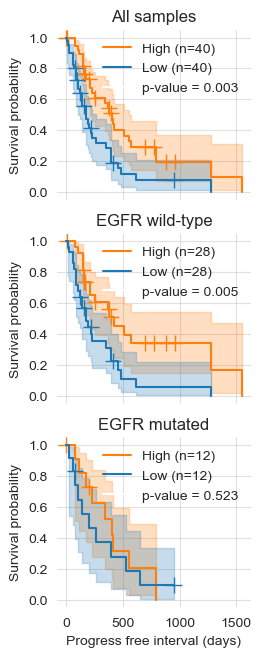

In [8]:
f, axes = plt.subplots(3, 1, figsize=(2.5, 7.5), sharex=True)
# f.subplots_adjust(hspace=0.5)

QuantileSampleSplitPlot(dftcga, gene = 'score', q=0.25, ax = axes[0], show_censors=True)
QuantileSampleSplitPlot(dftcga.query("EGFR_mut==0"), gene = 'score', q=0.25, ax = axes[1], show_censors=True)
QuantileSampleSplitPlot(dftcga.query("EGFR_mut==1"), gene = 'score', q=0.25, ax = axes[2], show_censors=True)
axes[0].set_title('All samples')
axes[1].set_title('EGFR wild-type')
axes[2].set_title('EGFR mutated')

for ax in axes:
    ax.set_xlabel('Progress free interval (days)')
    ax.set_ylabel('Survival probability')

f.savefig('../assets/ZhaoSim2021/EGFR_mut_TCGA_survival.pdf', bbox_inches='tight')

In [39]:
import pandas as pd
import numpy as np

def extract_df(cph, model_name):
    df = cph.summary.reset_index().rename(columns={'index': 'covariate'})
    # df = df[['covariate', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
    df['-log2(p)'] = -np.log2(df['p'])
    df['model'] = model_name
    df = df.rename(columns={
        'coef': 'HR',
        'coef lower 95%': 'CI_lower',
        'coef upper 95%': 'CI_upper'
    })
    return df

df_all = extract_df(cph_all, 'All')
df_mut = extract_df(cph_mut, 'EGFR-mut')
df_wt  = extract_df(cph_wt,  'EGFR-wt')

df_plot = pd.concat([df_all, df_mut, df_wt], ignore_index=True)
df_plot

,covariate,HR,exp(coef),se(coef),CI_lower,CI_upper,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p),model
0,score,-1.509706,0.220975,0.530347,-2.549167,-0.470245,0.078147,0.624849,0.0,-2.846639,0.004418,7.822279,All
1,EGFR_mut,0.214942,1.239790,0.202608,-0.182163,0.612048,0.833466,1.844204,0.0,1.060876,0.288746,1.792125,All
2,age,0.013488,1.013580,0.007840,-0.001878,0.028854,0.998124,1.029275,0.0,1.720479,0.085345,3.550543,All
3,gender[T.MALE],0.199279,1.220522,0.192001,-0.177037,0.575595,0.837749,1.778188,0.0,1.037904,0.299315,1.740265,All
4,race[T.BLACK OR AFRICAN AMERICAN],1.015550,2.760883,0.787714,-0.528341,2.559442,0.589582,12.928601,0.0,1.289237,0.197316,2.341423,All
5,race[T.WHITE],0.113017,1.119651,0.682132,-1.223938,1.449972,0.294070,4.262995,0.0,0.165682,0.868407,0.203557,All
6,EGFR_score_interaction,0.121106,1.128745,0.113646,-0.101637,0.343849,0.903358,1.410366,0.0,1.065640,0.286586,1.802958,All
7,score,0.366534,1.442726,0.913612,-1.424113,2.157181,0.240722,8.646732,0.0,0.401193,0.688278,0.538936,EGFR-mut
8,age,-0.014720,0.985388,0.015160,-0.044433,0.014993,0.956540,1.015106,0.0,-0.970990,0.331553,1.592687,EGFR-mut
9,gender[T.MALE],0.926937,2.526757,0.403158,0.136762,1.717111,1.146555,5.568418,0.0,2.299192,0.021494,5.539918,EGFR-mut


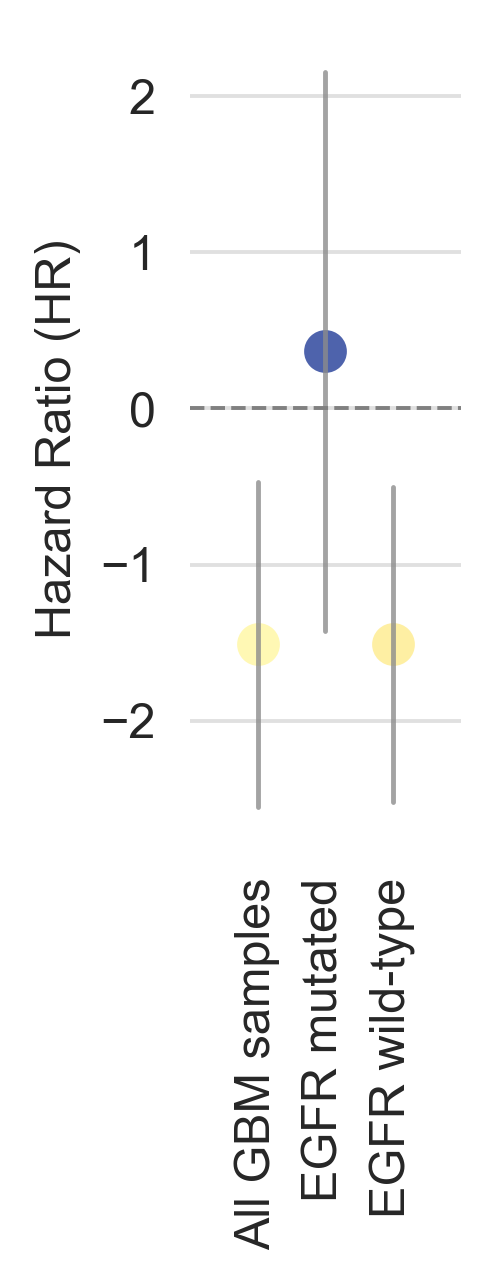

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

f = plt.figure(figsize=(1, 3), dpi=350)
df_plot = df_plot[df_plot['covariate'] == 'score'].reset_index(drop=True)
ax = sns.pointplot(
    data=df_plot,
    x="model",
    y="HR",
    hue="-log2(p)",
    hue_norm=(0, 15),
    palette="Spectral_r",
    join=False,
    markers="o",
    # scale=0.8
)

# Add CI bars (vertical)
for i, row in df_plot.iterrows():
    ax.plot(
        [i, i],
        [row["CI_lower"], row["CI_upper"]],
        color=".55",
        alpha=0.8,
        linewidth=1
    )

# Reference line at HR = 1
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)

# Clean up x‑axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel("")
ax.set_ylabel("Hazard Ratio (HR)")
ax.legend_.remove()
ax.set_xlim(-1, 3)
ax.set_xticklabels(['All GBM samples', 'EGFR mutated', 'EGFR wild-type'], rotation=90)
f.savefig('../assets/ZhaoSim2021/EGFR_mut_TCGA_survival_forest.pdf', bbox_inches='tight')

# Re-draw the data from cBioportal

### Co-Mutation

In [122]:
df = pd.read_table('../assets/topic32_genomics/table.tsv', index_col=0)
taget_genes = [
    'EGFR', 'SEC61G', 'LANCL2', 'VOPP1', 'CCT6A'
]
# df.query('Gene in @taget_genes', inplace=True)
df = df.loc[taget_genes, :]

In [123]:
import re
pat = re.compile(r'\d+ \((.+)%\)')
df['Altered group'] = df['Altered group'].str.extract(pat)[0].astype(float)
df['Unaltered group'] = df['Unaltered group'].str.extract(pat)[0].astype(float)

In [124]:
df[['Altered group', 'Unaltered group']].reset_index().melt(id_vars='Gene', var_name='Group', value_name='Percentage')

,Gene,Group,Percentage
0,EGFR,Altered group,57.98
1,SEC61G,Altered group,48.50
2,LANCL2,Altered group,45.02
3,VOPP1,Altered group,41.33
4,CCT6A,Altered group,32.84
5,EGFR,Unaltered group,40.75
6,SEC61G,Unaltered group,28.28
7,LANCL2,Unaltered group,19.49
8,VOPP1,Unaltered group,12.90
9,CCT6A,Unaltered group,0.05


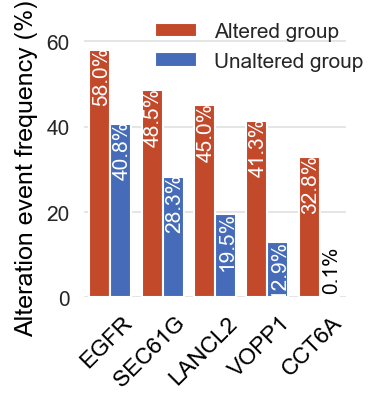

In [129]:
# sns.barplot(
#     data=df.reset_index(),
#     x = 'Gene',
#     y = ['Altered group	', 'Unaltered group']
# )
scale = 0.75
f, ax = plt.subplots(1,1, figsize=(3*scale,3*scale), dpi=150)
sns.barplot(
    data=df[['Altered group', 'Unaltered group']].reset_index().melt(id_vars='Gene', var_name='Group', value_name='Percentage'),
    x = 'Gene',
    y = 'Percentage',
    hue = 'Group',
    palette = ['#dc3912', '#3366cc'], 
    ax = ax
)
ax.set_ylabel("Alteration event frequency (%)", fontsize=12, color='black')
ax.set_xlabel("")
ax.legend(title='', frameon=False, bbox_to_anchor=(0.2,0.8))
ax.set_xticks(np.arange(len(df))+0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11, color='black')


# add value labels
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height == 0:
        continue
    
    if height > 10:
        height -= 13
        color = 'white'
    else:
        height += 1
        color = 'black'

    if i < len(df):
        value = df['Altered group'].iloc[i]
    else:
        value = df['Unaltered group'].iloc[i - len(df)]

    ax.text(
        x = p.get_x() + p.get_width() / 2+0.03,
        y = height,
        s = f'{value:.1f}%',
        color = color,
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
        rotation = 90,
    )
ax.set_xticks(np.arange(5)+0.5)
ax.set_xticklabels(target_genes)
f.savefig('../assets/topic32_genomics/alteration_frequency.pdf', bbox_inches='tight')